In [ ]:
!pip install -r requirements.txt

In [2]:
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, AutoConfig, TrainingArguments, Trainer, BertModel, EarlyStoppingCallback
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from pypinyin import pinyin, Style
import torch
import torch.nn as nn
import numpy as np
import evaluate
import pandas as pd
import os
import pronouncing

In [3]:
# ============================================================
# DEVICE CONFIGURATION - Set USE_GPU to True if GPU available
# ============================================================
import torch

USE_GPU = True  # Set to True if you have GPU (CUDA/MPS)

# Detect available device
if USE_GPU:
    if torch.cuda.is_available():
        device = "cuda"
        print("✅ GPU (CUDA) detected and enabled")
    elif torch.backends.mps.is_available():
        device = "mps"  # Mac with Apple Silicon
        print("✅ GPU (MPS) detected and enabled")
    else:
        device = "cpu"
        print("⚠️ GPU requested but not available, falling back to CPU")
else:
    device = "cpu"
    print("✅ Using CPU (set USE_GPU=True to enable GPU)")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device.upper()}")

✅ GPU (CUDA) detected and enabled
PyTorch version: 2.10.0+cu128
Device: CUDA


### Data Preprocessing

In [4]:
data_path = "./toxic_dataset_cleaned.csv"
df = pd.read_csv(data_path).dropna(subset=['text', 'label'])
df['text'] = df['text'].astype(str)
df['label'] = df['label'].astype(int)

X_train, X_val, y_train, y_val = train_test_split(
    df["text"], df["label"], test_size=0.2, random_state=42, stratify=df["label"]
)

dataset = DatasetDict({
    "train": Dataset.from_pandas(pd.DataFrame({"text": X_train.values, "label": y_train.values}), preserve_index=False),
    "validation": Dataset.from_pandas(pd.DataFrame({"text": X_val.values, "label": y_val.values}), preserve_index=False)
})

## Context Model

### Define Model

In [5]:
from transformers import AutoTokenizer

model_name = "google-bert/bert-base-chinese"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

# Map the function over the entire dataset in batches
tokenized_datasets = dataset.map(tokenize_function, batched=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/624 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/520 [00:00<?, ? examples/s]

Map:   0%|          | 0/131 [00:00<?, ? examples/s]

### Train

In [6]:
accuracy = evaluate.load("accuracy")
f1_macro = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy.compute(predictions=preds, references=labels)["accuracy"],
        "f1_macro": f1_macro.compute(predictions=preds, references=labels, average="macro")["f1"]
    }

In [7]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

# 1. Load model with a classification head
# num_labels should match the number of unique classes in your dataset
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

# 2. Define training hyperparameters
training_args = TrainingArguments(
    output_dir="./baseline_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    num_train_epochs=15,
    load_best_model_at_end=True,
    weight_decay=0.01,
    metric_for_best_model="f1_macro",
)

# 3. Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=8)],
)

# 4. Start training
trainer.train()

model.safetensors:   0%|          | 0.00/412M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-chinese
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,No log,0.627834,0.679389,0.546040
2,No log,0.567344,0.702290,0.646607
3,No log,0.555944,0.709924,0.662737
4,No log,0.689801,0.702290,0.635722
5,No log,0.635418,0.740458,0.698238
6,No log,0.561298,0.732824,0.702215
7,No log,0.546185,0.770992,0.757407
8,No log,0.587514,0.770992,0.748721
9,No log,0.727820,0.770992,0.733740
10,No log,0.650566,0.770992,0.753389


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=495, training_loss=0.22471942323626895, metrics={'train_runtime': 363.2281, 'train_samples_per_second': 21.474, 'train_steps_per_second': 1.363, 'total_flos': 513066557952000.0, 'train_loss': 0.22471942323626895, 'epoch': 15.0})

### Inference

In [8]:
def predict(text):
    # 1. Tokenize
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=128).to(device)

    # 2. Forward Pass
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)

    # 3. Get Label
    logits = outputs.logits
    pred_idx = torch.argmax(logits, dim=-1).item()

    return "Toxic" if pred_idx == 1 else "Non-Toxic"

# Now this will work:
print(predict("你好"))

Toxic


In [9]:
predict("你好")

'Toxic'

In [11]:
# 11. Confusion Matrix & Classification Report
predictions = trainer.predict(tokenized_datasets["validation"])
y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=-1)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, labels=[0, 1], target_names=["Non-Toxic", "Toxic"]))


Classification Report:
              precision    recall  f1-score   support

   Non-Toxic       0.82      0.80      0.81        82
       Toxic       0.69      0.71      0.70        49

    accuracy                           0.77       131
   macro avg       0.76      0.76      0.76       131
weighted avg       0.77      0.77      0.77       131



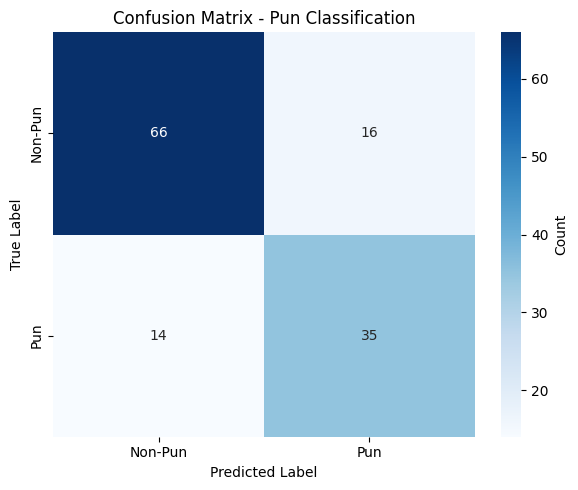


✅ Model training completed!


In [12]:
# Plot confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non-Pun", "Pun"],
            yticklabels=["Non-Pun", "Pun"],
            cbar_kws={'label': 'Count'})
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Pun Classification")
plt.tight_layout()
plt.show()

print("\n✅ Model training completed!")